In [21]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm

df = sns.load_dataset("iris") # hoac : from sklearn . datasets

print(df.head ())
print(df.shape)
print(df.dtypes)

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
(150, 5)
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


In [17]:
summary = df.describe().T
summary["var"] = df.var(numeric_only=True)
summary["mode"] = df.mode(numeric_only=True).iloc[0]
summary["IQR"] = summary["75%"] - summary["25%"]
summary

,count,mean,std,min,25%,50%,75%,max,var,mode,IQR
sepal_length,150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9,0.685694,5.0,1.3
sepal_width,150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4,0.189979,3.0,0.5
petal_length,150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9,3.116278,1.4,3.5
petal_width,150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5,0.581006,0.2,1.5


In [20]:
df.groupby("species").agg(["mean", "std"])

sepal_length           sepal_width           petal_length  \
                   mean       std        mean       std         mean   
species                                                                
setosa            5.006  0.352490       3.428  0.379064        1.462   
versicolor        5.936  0.516171       2.770  0.313798        4.260   
virginica         6.588  0.635880       2.974  0.322497        5.552   

                     petal_width            
                 std        mean       std  
species                                     
setosa      0.173664       0.246  0.105386  
versicolor  0.469911       1.326  0.197753  
virginica   0.551895       2.026  0.274650

Nhóm có sự khác biệt rõ rệt nhất: Loài setosa tách biệt hoàn toàn so với hai loài còn lại  
Lý do cụ thể: Nếu nhìn vào chỉ số mean của kích thước cánh hoa (petal_length và petal_width), loài setosa có kích thước nhỏ hơn hẳn (trung bình petal_length chỉ khoảng 1.46 cm, so với versicolor khoảng 4.26 cm và virginica khoảng 5.55 cm).  
-Độ lệch chuẩn (std) về kích thước cánh hoa của loài setosa cũng rất nhỏ, chứng tỏ các cá thể trong loài này có kích thước đồng đều và tập trung, tạo nên một cụm dữ liệu tách biệt hoàn toàn.  
-Ngược lại, hai loài versicolor và virginica có các chỉ số trung bình tiệm cận nhau hơn và có sự chồng lấn nhẹ về mặt không gian dữ liệu

In [30]:
numeric_features = df.select_dtypes(include=['float64', 'int64']).columns
numeric_features

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width'], dtype='object')

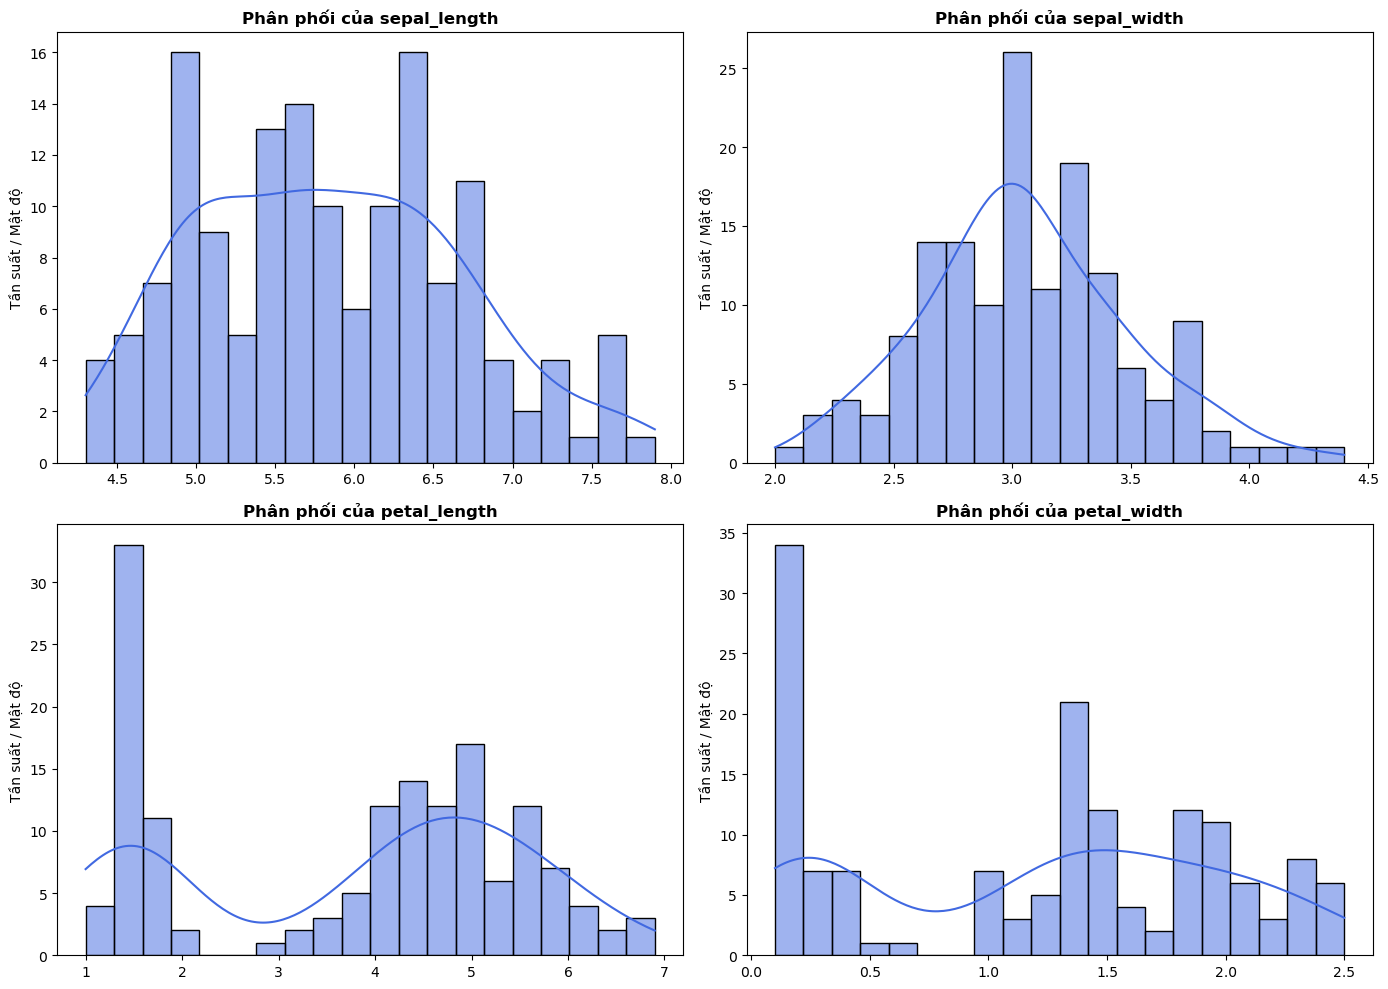

In [25]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    sns.histplot(data=df, x=feature, kde=True, ax=axes[i], color='royalblue', bins=20)
    axes[i].set_title(f'Phân phối của {feature}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Tần suất / Mật độ')

plt.tight_layout()
plt.show()

Nhận xét:  
sepal_length và sepal_width: Có hình dạng tương đối đối xứng, tập trung nhiều ở giữa và thấp dần về hai bên. Phân phối của hai biến này gần với phân phối chuẩn (Normal Distribution).  
petal_length và petal_width: Biểu đồ hiển thị tách biệt rõ ràng thành hai đỉnh lớn (Bimodal/Multi-modal Distribution). Có một khoảng trống (vùng thung lũng có tần suất bằng 0) ở giữa. Điều này xảy ra do sự khác biệt kích thước quá lớn giữa loài setosa (nhỏ hẳn) và hai loài còn lại.  

C:\Users\Windows\AppData\Local\Temp\ipykernel_23656\3528738472.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=feature, ax=axes[i], palette='Set2')
C:\Users\Windows\AppData\Local\Temp\ipykernel_23656\3528738472.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=feature, ax=axes[i], palette='Set2')
C:\Users\Windows\AppData\Local\Temp\ipykernel_23656\3528738472.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=feature, ax=axes[i], palette='Set2')
C:\Users\Windows\Ap

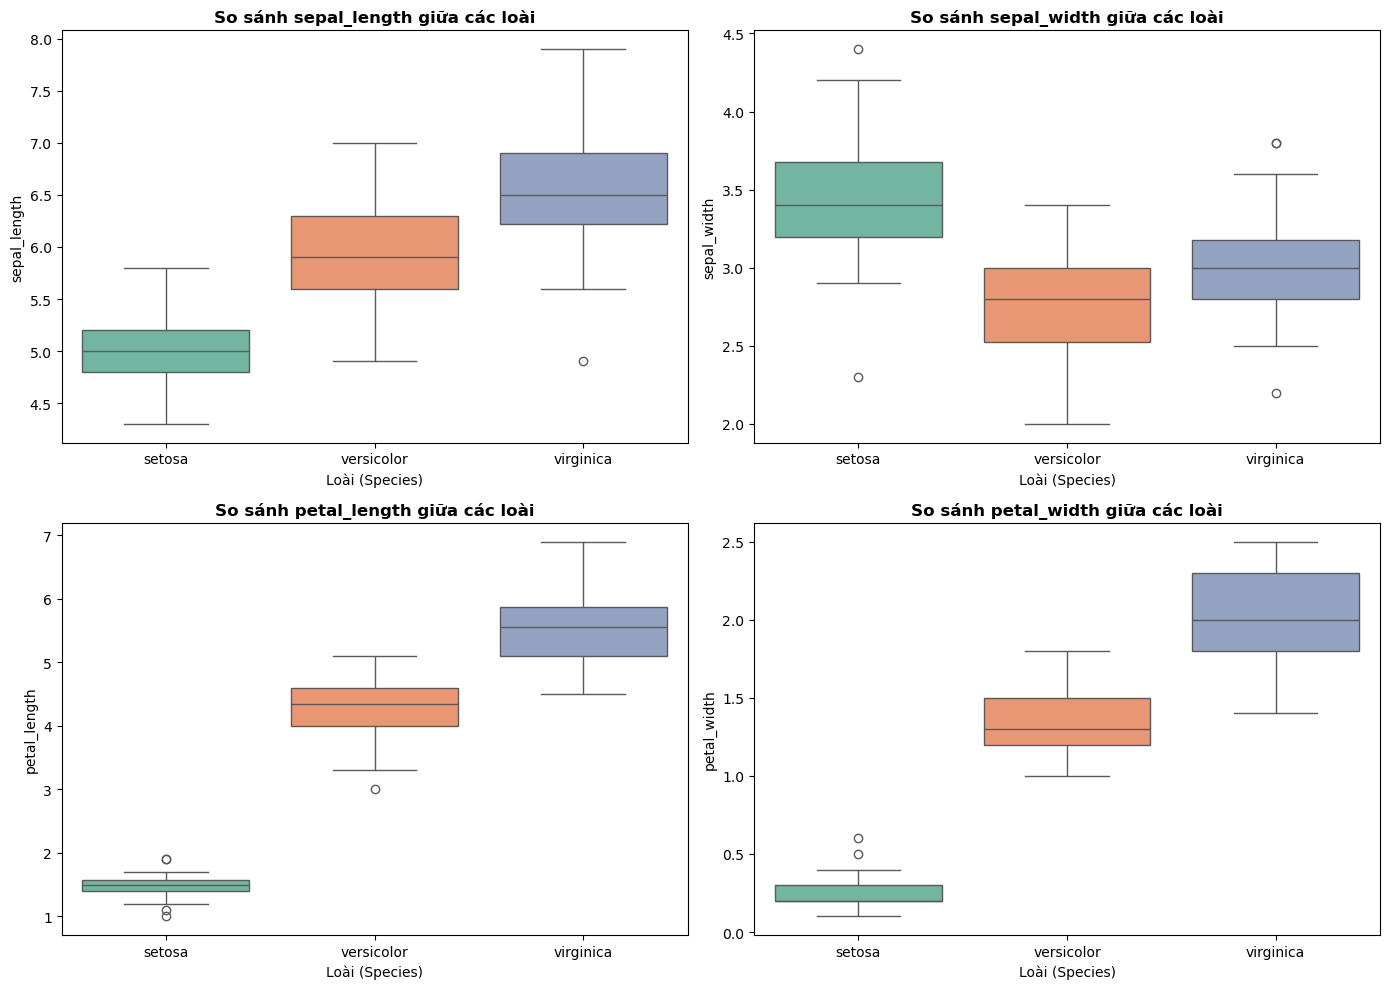

In [27]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    sns.boxplot(data=df, x='species', y=feature, ax=axes[i], palette='Set2')
    axes[i].set_title(f'So sánh {feature} giữa các loài', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Loài (Species)')
    axes[i].set_ylabel(feature)

plt.tight_layout()
plt.show()

Kích thước cánh hoa (petal_length, petal_width) của loài setosa cực kỳ nhỏ và đồng đều (hộp rất hẹp), tách biệt hoàn toàn khỏi versicolor và virginica.  
Biến sepal_width của các loài có độ rộng hộp tương đối giống nhau nhưng có xuất hiện vài điểm ngoại lai (outliers) nằm ngoài khoảng râu (whiskers).

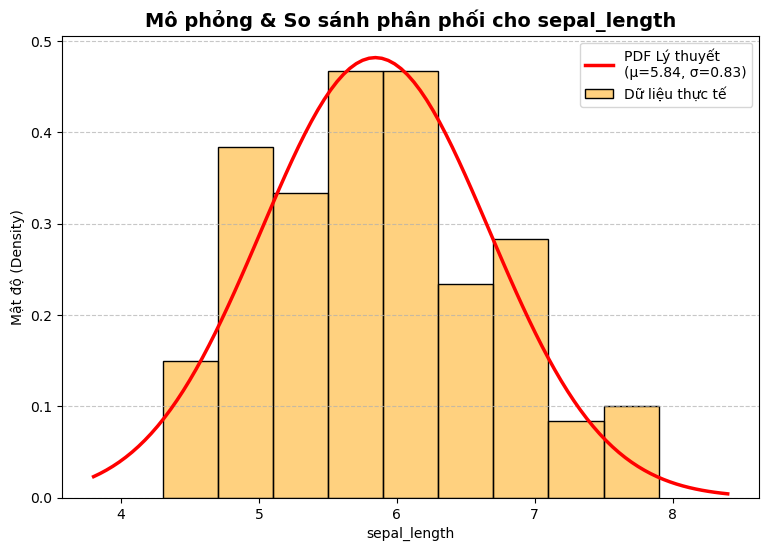

In [28]:
chosen_feature = 'sepal_length'

mu = df[chosen_feature].mean()
sigma = df[chosen_feature].std()

plt.figure(figsize=(9, 6))
sns.histplot(data=df, x=chosen_feature, stat='density', alpha=0.5, color='orange', label='Dữ liệu thực tế')

x_axis = np.linspace(df[chosen_feature].min() - 0.5, df[chosen_feature].max() + 0.5, 100)
pdf_theoretical = norm.pdf(x_axis, mu, sigma)

plt.plot(x_axis, pdf_theoretical, color='red', linewidth=2.5, label=f'PDF Lý thuyết\n(μ={mu:.2f}, σ={sigma:.2f})')

plt.title(f'Mô phỏng & So sánh phân phối cho {chosen_feature}', fontsize=14, fontweight='bold')
plt.xlabel(chosen_feature)
plt.ylabel('Mật độ (Density)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Mức độ khớp: Đường cong PDF lý thuyết (màu đỏ) bao bọc khá sát và mô phỏng tương đối tốt hình dáng của Histogram dữ liệu thực tế (màu orange).  
Chi tiết: Đỉnh của dữ liệu thực tế tập trung rất gần với giá trị trung bình lý thuyết $\mu \approx 5.84$. Tuy nhiên, do kích thước tập dữ liệu Iris khá nhỏ (chỉ có 150 mẫu), biểu đồ histogram thực tế vẫn có những đoạn nhấp nhô chưa hoàn toàn nhẵn mịn tuyệt đối như đường cong toán học lý thuyết, nhưng nhìn chung là độ khớp cao.

In [31]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])
print("--- Ma trận Hiệp phương sai (Covariance Matrix) ---")
cov_matrix = numeric_df.cov()
print(cov_matrix)

print("\n--- Ma trận Tương quan (Correlation Matrix) ---")
corr_matrix = numeric_df.corr()
print(corr_matrix)

--- Ma trận Hiệp phương sai (Covariance Matrix) ---
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      0.685694    -0.042434      1.274315     0.516271
sepal_width      -0.042434     0.189979     -0.329656    -0.121639
petal_length      1.274315    -0.329656      3.116278     1.295609
petal_width       0.516271    -0.121639      1.295609     0.581006

--- Ma trận Tương quan (Correlation Matrix) ---
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.117570      0.871754     0.817941
sepal_width      -0.117570     1.000000     -0.428440    -0.366126
petal_length      0.871754    -0.428440      1.000000     0.962865
petal_width       0.817941    -0.366126      0.962865     1.000000


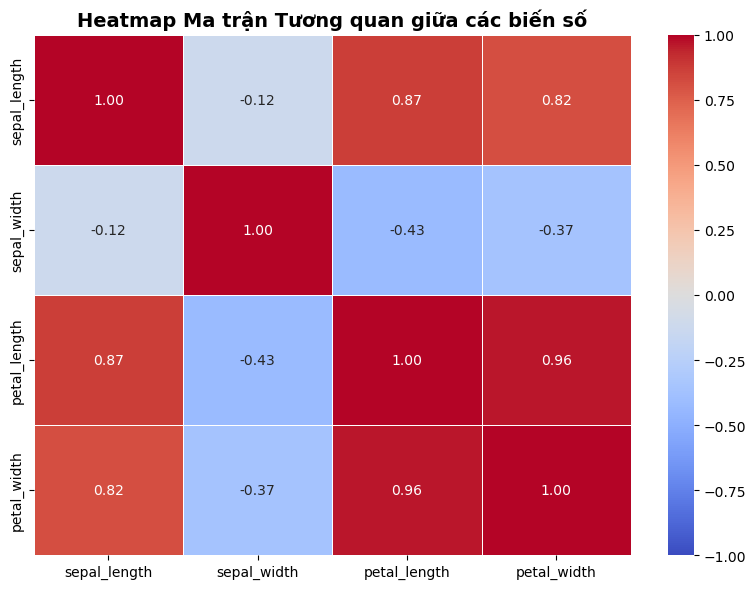

In [33]:
plt.figure(figsize=(8, 6))
# annot=True để hiện số, cmap để chọn bảng màu, fmt='.2f' lấy 2 chữ số thập phân
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title("Heatmap Ma trận Tương quan giữa các biến số", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Cặp biến tương quan mạnh nhất: Cặp biến petal_length và petal_width có hệ số tương quan tuyến tính cao nhất, đạt tới 0.96 (tương quan thuận gần như hoàn hảo). Bên cạnh đó, cặp sepal_length và petal_length cũng tương quan rất mạnh (0.87).  
Dấu hiệu đa cộng tuyến (Multicollinearity): Có dấu hiệu đa cộng tuyến rõ rệt. Trong thống kê, khi hệ số tương quan giữa các biến độc lập vượt quá 0.85 hoặc 0.90, hiện tượng đa cộng tuyến rất dễ xảy ra. Việc petal_length, petal_width và sepal_length đồng biến mạnh mẽ với nhau có nghĩa là chúng mang lượng thông tin trùng lặp lớn. Nếu đưa tất cả các biến này vào một số mô hình hồi quy tuyến tính (Linear Regression) mà không xử lý, nó có thể làm nhiễu và mất ổn định các hệ số hồi quy.

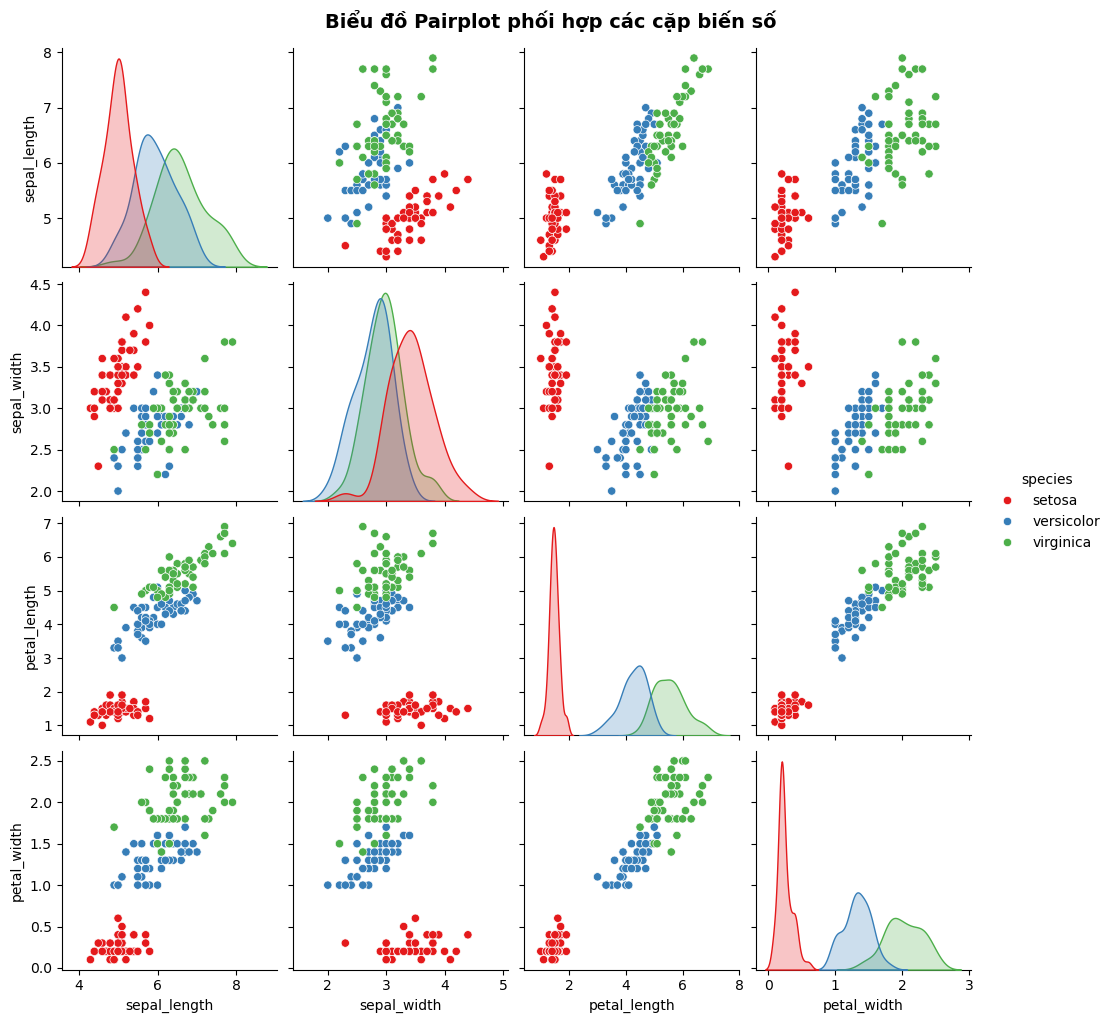

In [34]:
sns.pairplot(df, hue='species', palette='Set1', diag_kind='kde')
plt.suptitle("Biểu đồ Pairplot phối hợp các cặp biến số", y=1.02, fontsize=14, fontweight='bold')
plt.show()

Sự phân tách giữa các loài: Biểu đồ pairplot cho thấy loài setosa (màu đỏ) luôn tạo thành một cụm biệt lập, tách rời hoàn toàn khỏi hai loài còn lại ở hầu hết các biểu đồ scatter phối hợp cặp biến (đặc biệt là các góc nhìn liên quan đến petal_length và petal_width).  

Mối quan hệ tuyến tính: Hai loài versicolor và virginica có xu hướng nằm gần nhau và có sự chồng lấn (overlap) nhẹ về không gian dữ liệu, nhưng chúng vẫn tạo ra một xu hướng tuyến tính rõ rệt: khi kích thước đài hoa (sepal) tăng thì kích thước cánh hoa (petal) của chúng nhìn chung cũng tăng theo dáng đồ thị dốc lên.

In [35]:
P_B = 0.01                 # Tỉ lệ mắc bệnh trong dân số
P_pos_givenB = 0.99        # Độ nhạy P(+ | B)
P_pos_givenNB = 0.05       # Dương tính giả P(+ | ¬B)

In [36]:
P_pos = P_pos_givenB * P_B + P_pos_givenNB * (1 - P_B)
P_B_given_pos = (P_pos_givenB * P_B) / P_pos

In [37]:
print(f"Xác suất một người thực sự mắc bệnh khi có kết quả dương tính là: {round(P_B_given_pos, 4)}")

Xác suất một người thực sự mắc bệnh khi có kết quả dương tính là: 0.1667


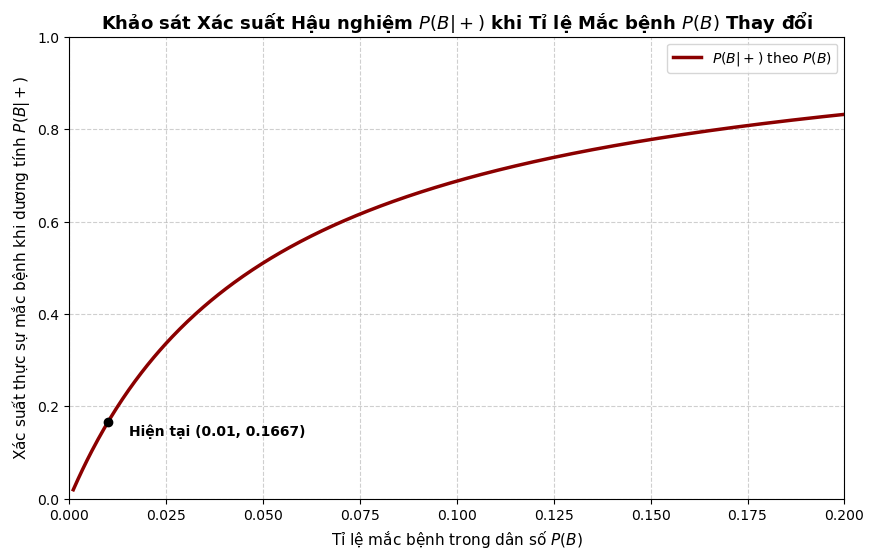

In [38]:
P_B_range = np.linspace(0.001, 0.2, 500)

P_pos_range = P_pos_givenB * P_B_range + P_pos_givenNB * (1 - P_B_range)
P_B_given_pos_range = (P_pos_givenB * P_B_range) / P_pos_range

plt.figure(figsize=(10, 6))
plt.plot(P_B_range, P_B_given_pos_range, color='darkred', linewidth=2.5, label='$P(B|+)$ theo $P(B)$')

plt.scatter(0.01, P_B_given_pos, color='black', zorder=5)
plt.annotate(f'Hiện tại (0.01, {P_B_given_pos:.4f})', (0.01, P_B_given_pos), 
             textcoords="offset points", xytext=(15,-10), ha='left', fontweight='bold')

plt.title('Khảo sát Xác suất Hậu nghiệm $P(B|+)$ khi Tỉ lệ Mắc bệnh $P(B)$ Thay đổi', fontsize=13, fontweight='bold')
plt.xlabel('Tỉ lệ mắc bệnh trong dân số $P(B)$', fontsize=11)
plt.ylabel('Xác suất thực sự mắc bệnh khi dương tính $P(B|+)$', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(0, 0.2)
plt.ylim(0, 1)
plt.legend()
plt.show()

- Do bệnh quá hiếm trong cộng đồng ($P(B) = 1\%$, nghĩa là cứ 10.000 người thì chỉ có 100 người bệnh, còn lại tận 9.900 người khỏe mạnh).
- Xét nghiệm dù tốt nhưng vẫn dính lỗi dương tính giả $5\%$. Khi áp dụng lên nhóm $9.900$ người khỏe mạnh, số ca bị báo sai (dương tính giả) sẽ là: $9.900 \times 5\% = \mathbf{495\text{ người}}$.
- Trong khi đó, xét nghiệm phát hiện được chính xác nhóm người bệnh thật là: $100 \times 99\% = \mathbf{99\text{ người}}$.
- Tổng số ca nhận được giấy báo "Dương tính" là: $495 \text{ (giả)} + 99 \text{ (thật)} = 594\text{ người}$. 
- Vì vậy, một người cầm tờ kết quả dương tính trên tay thì cơ hội họ nằm trong nhóm bệnh thật chỉ là: $\frac{99}{594} \approx 16.67\%$.
> Kết luận rút ra từ đồ thị: Khi $P(B)$ tiến dần về $0$ (bệnh cực kỳ hiếm), đồ thị dốc xuống rất nhanh chỉ về sát mức $0$. Định lý Bayes cho thấy đối với các bệnh hiếm, các ca Dương tính giả ở nhóm người khỏe mạnh sẽ hoàn toàn "áp đảo" số ca Dương tính thật, khiến cho giá trị dự đoán dương tính bị kéo giảm mạnh.

In [42]:
P_spam = 0.4
P_not_spam = 0.6
word_probs = {
    'khuyến_mãi': {'spam': 0.8, 'not_spam': 0.1},
    'trúng_thưởng': {'spam': 0.7, 'not_spam': 0.01},
    'học_tập':     {'spam': 0.05, 'not_spam': 0.6}
}
emails = {
    "Email 1": ['khuyến_mãi', 'trúng_thưởng'],
    "Email 2": ['học_tập'],
    "Email 3": ['khuyến_mãi', 'học_tập']
}

for name, words in emails.items():
    posterior_spam_score = P_spam
    posterior_not_spam_score = P_not_spam
    
    for word in words:
        if word in word_probs:
            posterior_spam_score *= word_probs[word]['spam']
            posterior_not_spam_score *= word_probs[word]['not_spam']
            
    P_spam_given_email = posterior_spam_score / (posterior_spam_score + posterior_not_spam_score)
    print(f"{name} chứa các từ {words} -> P(Spam | Email) = {P_spam_given_email:.4f}")

Email 1 chứa các từ ['khuyến_mãi', 'trúng_thưởng'] -> P(Spam | Email) = 0.9973
Email 2 chứa các từ ['học_tập'] -> P(Spam | Email) = 0.0526
Email 3 chứa các từ ['khuyến_mãi', 'học_tập'] -> P(Spam | Email) = 0.3077
